# Umbilicus Detection using YOLOv26

This notebook demonstrates a complete workflow for training and evaluating an object detection model for umbilicus localization using the YOLOv26 architecture.

The notebook includes dataset verification, model training, evaluation of training metrics, and inference on validation images.

## Table of Contents

0. Setup & Environment  
1. Import Libraries  
2. Dataset Overview  
3. Dataset Verification  
4. Dataset Visualization  
5. YOLO Dataset Configuration  
6. Model Training  
7. Training Results  
8. Model Inference  
9. Gradio Interface
10. Discussion and Conclusion


## 0. Setup & Environment

This section installs the required libraries and prepares the environment for training and running the YOLO object detection model.

In [5]:
# Install
%pip install -U ultralytics pillow matplotlib pyyaml

#1.import libraries
import os
import glob
import yaml
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image

from ultralytics import YOLO

In [6]:
#import libraries
import os
import glob
import yaml
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image

from ultralytics import YOLO

## 2. Dataset Overview

The dataset contains abdominal images with bounding box annotations around the umbilicus.

Images are organized into training(70%), validation(20%), and test(10%) sets following the standard YOLO dataset structure.

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3. Dataset Verification

Before training the model, we verify that the dataset structure is correct.  
This includes checking directory paths and ensuring that image and label files exist.

In [8]:
print("Current working directory:")
print(os.getcwd())

print("\nFiles/folders in current directory:")
print(os.listdir())

Current working directory:
/content

Files/folders in current directory:
['.config', 'runs', 'drive', 'yolo26n.pt', 'sample_data']


In [9]:
import os

DATASET_ROOT = "/content/drive/MyDrive/YOLO8.v3i.yolo26"
DATA_YAML = os.path.join(DATASET_ROOT, "data.yaml")

TRAIN_IMAGES = os.path.join(DATASET_ROOT, "train", "images")
TRAIN_LABELS = os.path.join(DATASET_ROOT, "train", "labels")

VALID_IMAGES = os.path.join(DATASET_ROOT, "valid", "images")
VALID_LABELS = os.path.join(DATASET_ROOT, "valid", "labels")

TEST_IMAGES = os.path.join(DATASET_ROOT, "test", "images")
TEST_LABELS = os.path.join(DATASET_ROOT, "test", "labels")

PROJECT_DIR = "/content/drive/MyDrive/umbilicus_yolo26"

RUN_NAME = "trial1"
MODEL_NAME = "yolo26n.pt"

### Path Check

The following cell checks whether all important dataset paths exist.  
If any path returns `False`, it should be corrected before proceeding.

In [10]:
paths_to_check = {
    "DATASET_ROOT": DATASET_ROOT,
    "DATA_YAML": DATA_YAML,
    "TRAIN_IMAGES": TRAIN_IMAGES,
    "TRAIN_LABELS": TRAIN_LABELS,
    "VALID_IMAGES": VALID_IMAGES,
    "VALID_LABELS": VALID_LABELS,
    "TEST_IMAGES": TEST_IMAGES,
    "TEST_LABELS": TEST_LABELS,
    "PROJECT_DIR": PROJECT_DIR,
}

for name, path in paths_to_check.items():
    print(f"{name}:")
    print(path)
    print("Exists:", os.path.exists(path))
    print("-" * 60)

DATASET_ROOT:
/content/drive/MyDrive/YOLO8.v3i.yolo26
Exists: True
------------------------------------------------------------
DATA_YAML:
/content/drive/MyDrive/YOLO8.v3i.yolo26/data.yaml
Exists: True
------------------------------------------------------------
TRAIN_IMAGES:
/content/drive/MyDrive/YOLO8.v3i.yolo26/train/images
Exists: True
------------------------------------------------------------
TRAIN_LABELS:
/content/drive/MyDrive/YOLO8.v3i.yolo26/train/labels
Exists: True
------------------------------------------------------------
VALID_IMAGES:
/content/drive/MyDrive/YOLO8.v3i.yolo26/valid/images
Exists: True
------------------------------------------------------------
VALID_LABELS:
/content/drive/MyDrive/YOLO8.v3i.yolo26/valid/labels
Exists: True
------------------------------------------------------------
TEST_IMAGES:
/content/drive/MyDrive/YOLO8.v3i.yolo26/test/images
Exists: True
------------------------------------------------------------
TEST_LABELS:
/content/drive/MyDriv

In [11]:
print("DATASET_ROOT exists:", os.path.exists(DATASET_ROOT))
print("DATA_YAML exists:", os.path.exists(DATA_YAML))

DATASET_ROOT exists: True
DATA_YAML exists: True


In [12]:
def count_files(folder, extensions=None):
    if not os.path.exists(folder):
        return 0
    if extensions is None:
        return len(os.listdir(folder))

    files = []
    for ext in extensions:
        files.extend(glob.glob(os.path.join(folder, f"*.{ext}")))
    return len(files)

image_exts = ["jpg", "jpeg", "png"]

print("Train images:", count_files(TRAIN_IMAGES, image_exts))
print("Train labels:", count_files(TRAIN_LABELS, ["txt"]))

print("Valid images:", count_files(VALID_IMAGES, image_exts))
print("Valid labels:", count_files(VALID_LABELS, ["txt"]))

print("Test images:", count_files(TEST_IMAGES, image_exts))
print("Test labels:", count_files(TEST_LABELS, ["txt"]))

Train images: 123
Train labels: 123
Valid images: 35
Valid labels: 35
Test images: 18
Test labels: 18


## 4. Dataset Visualization

Visualizing sample images helps confirm that the dataset is loaded correctly and provides an overview of the image content before training.

Number of sample training images found: 123


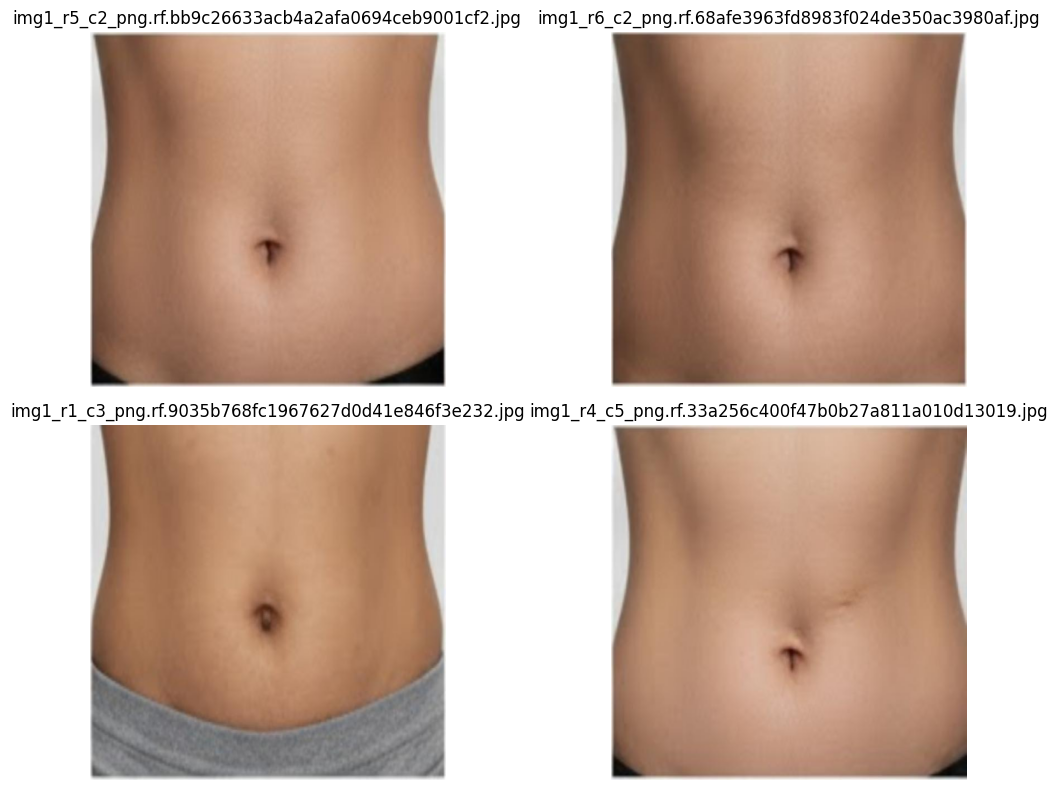

In [13]:
sample_images = (
    glob.glob(os.path.join(TRAIN_IMAGES, "*.jpg")) +
    glob.glob(os.path.join(TRAIN_IMAGES, "*.jpeg")) +
    glob.glob(os.path.join(TRAIN_IMAGES, "*.png"))
)

print("Number of sample training images found:", len(sample_images))

if len(sample_images) > 0:
    plt.figure(figsize=(12, 8))
    for i, img_path in enumerate(sample_images[:4]):
        img = Image.open(img_path)
        plt.subplot(2, 2, i + 1)
        plt.imshow(img)
        plt.title(os.path.basename(img_path))
        plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No training images found.")

## 5. YOLO Dataset Configuration

The dataset configuration is defined in the `data.yaml` file.  
This file specifies the training and validation paths, as well as the object class used for detection.

In [14]:
if os.path.exists(DATA_YAML):
    with open(DATA_YAML, "r", encoding="utf-8") as f:
        data_config = yaml.safe_load(f)

    print("Contents of data.yaml:")
    print(data_config)
else:
    raise FileNotFoundError(f"data.yaml not found: {DATA_YAML}")

Contents of data.yaml:
{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 1, 'names': ['umbilicus'], 'roboflow': {'workspace': 'tanyaporns-workspace', 'project': 'yolo8-h7vko', 'version': 3, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/tanyaporns-workspace/yolo8-h7vko/dataset/3'}}


In [15]:
required_keys = ["train", "val", "names"]
missing_keys = [k for k in required_keys if k not in data_config]

if len(missing_keys) == 0:
    print("data.yaml contains all required keys.")
else:
    print("Missing keys in data.yaml:", missing_keys)

if "names" in data_config:
    print("\nClass names:")
    print(data_config["names"])

data.yaml contains all required keys.

Class names:
['umbilicus']


## 6. Model Training

In this section, the **YOLOv26 object detection model** is trained using the prepared dataset.

Transfer learning is applied by starting from a pretrained YOLO model and adapting it to the umbilicus detection task.

In [16]:
# Load pretrained YOLO model
model = YOLO(MODEL_NAME)

# Train the model
results = model.train(
    data=DATA_YAML,
    epochs=20,
    imgsz=640,
    batch=4,
    project=PROJECT_DIR,
    name=RUN_NAME
)

Ultralytics 8.4.26 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/YOLO8.v3i.yolo26/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=trial12, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pati

## 7. Training Results

After training, YOLO automatically generates training curves that summarize the model’s learning progress.

These curves include loss values and evaluation metrics such as precision, recall, and mean average precision.

In [17]:
RUN_DIR = results.save_dir
RESULTS_PNG = os.path.join(RUN_DIR, "results.png")
BEST_MODEL_PATH = os.path.join(RUN_DIR, "weights", "best.pt")
LAST_MODEL_PATH = os.path.join(RUN_DIR, "weights", "last.pt")

print("Run directory:", RUN_DIR)
print("RESULTS_PNG exists:", os.path.exists(RESULTS_PNG))
print("BEST_MODEL_PATH exists:", os.path.exists(BEST_MODEL_PATH))
print("LAST_MODEL_PATH exists:", os.path.exists(LAST_MODEL_PATH))

Run directory: /content/drive/MyDrive/umbilicus_yolo26/trial12
RESULTS_PNG exists: True
BEST_MODEL_PATH exists: True
LAST_MODEL_PATH exists: True


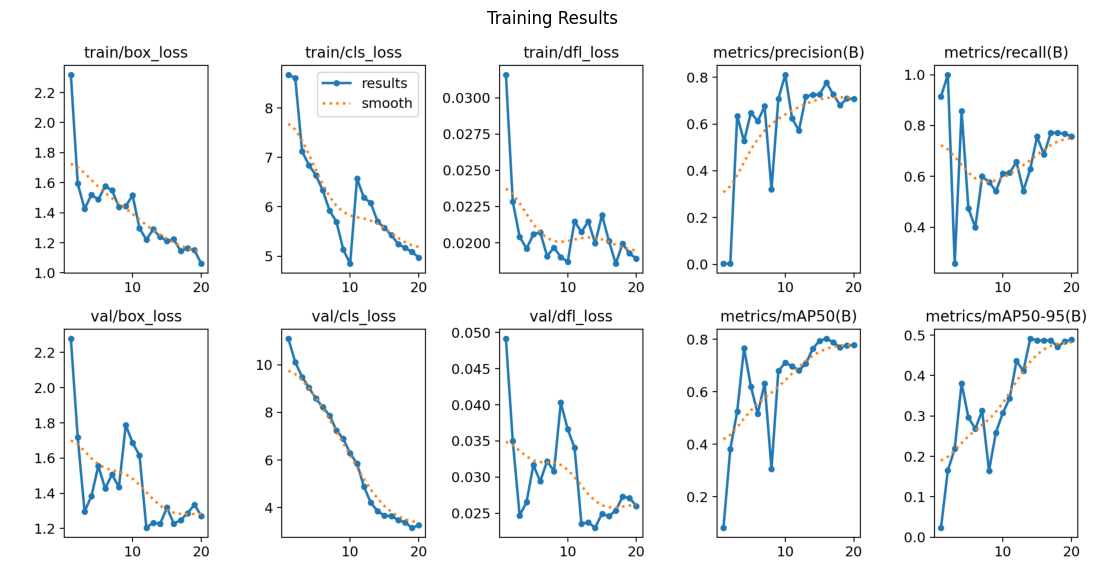

In [18]:
if os.path.exists(RESULTS_PNG):
    img = Image.open(RESULTS_PNG)
    plt.figure(figsize=(14, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Training Results")
    plt.show()
else:
    print("results.png not found.")

## 8. Model Inference

The trained model is used to perform inference on validation images.

The output includes bounding boxes showing the predicted location of the umbilicus.

In [19]:
if os.path.exists(BEST_MODEL_PATH):
    best_model = YOLO(BEST_MODEL_PATH)
    print("Best model loaded successfully.")
else:
    raise FileNotFoundError(f"best.pt not found: {BEST_MODEL_PATH}")

Best model loaded successfully.


In [20]:
best_model.predict(
    source=VALID_IMAGES,
    conf=0.25,
    save=True,
    show=True
)

WARNING ⚠️ Environment does not support cv2.imshow() or PIL Image.show()


image 1/35 /content/drive/MyDrive/YOLO8.v3i.yolo26/valid/images/img1_r2_c1_png.rf.cf9768099cbae5adc141eaa6cc863119.jpg: 640x640 2 umbilicuss, 11.9ms
image 2/35 /content/drive/MyDrive/YOLO8.v3i.yolo26/valid/images/img1_r2_c5_png.rf.7020352d00a7bdb9e62c9c36ba914b97.jpg: 640x640 2 umbilicuss, 13.4ms
image 3/35 /content/drive/MyDrive/YOLO8.v3i.yolo26/valid/images/img1_r3_c1_png.rf.a9c076bb1776c8d1ec7c0aa7cb678ce3.jpg: 640x640 2 umbilicuss, 12.7ms
image 4/35 /content/drive/MyDrive/YOLO8.v3i.yolo26/valid/images/img1_r4_c1_png.rf.234843c9dc8225fdb43ff754d8f6d2d1.jpg: 640x640 2 umbilicuss, 12.9ms
image 5/35 /content/drive/MyDrive/YOLO8.v3i.yolo26/valid/images/img1_r4_c4_png.rf.c660999cdd0b3e2aea733a75511787f5.jpg: 640x640 1 umbilicus, 11.4ms
image 6/35 /content/drive/MyDrive/YOLO8.v3i.yolo26/valid/images/img1_r5_c3_png.rf.c9e1b2a5f5c5a437065b3b01f941ecec.jpg: 640x640 2 umbilicuss, 11.3ms
image 7/35 /content/drive/MyDriv

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'umbilicus'}
 obb: None
 orig_img: array([[[242, 249, 252],
         [241, 248, 251],
         [240, 247, 250],
         ...,
         [251, 253, 253],
         [252, 254, 254],
         [252, 254, 254]],
 
        [[243, 250, 253],
         [242, 249, 252],
         [241, 248, 251],
         ...,
         [249, 251, 251],
         [250, 252, 252],
         [250, 252, 252]],
 
        [[244, 249, 250],
         [243, 248, 249],
         [239, 246, 249],
         ...,
         [247, 249, 249],
         [248, 250, 250],
         [249, 251, 251]],
 
        ...,
 
        [[215, 217, 217],
         [214, 216, 216],
         [213, 215, 215],
         ...,
         [220, 220, 220],
         [231, 231, 231],
         [238, 238, 238]],
 
        [[235, 240, 239],
         [234, 239, 238],
         [233, 238, 237],
         ...,
         [238, 

Number of prediction images: 35


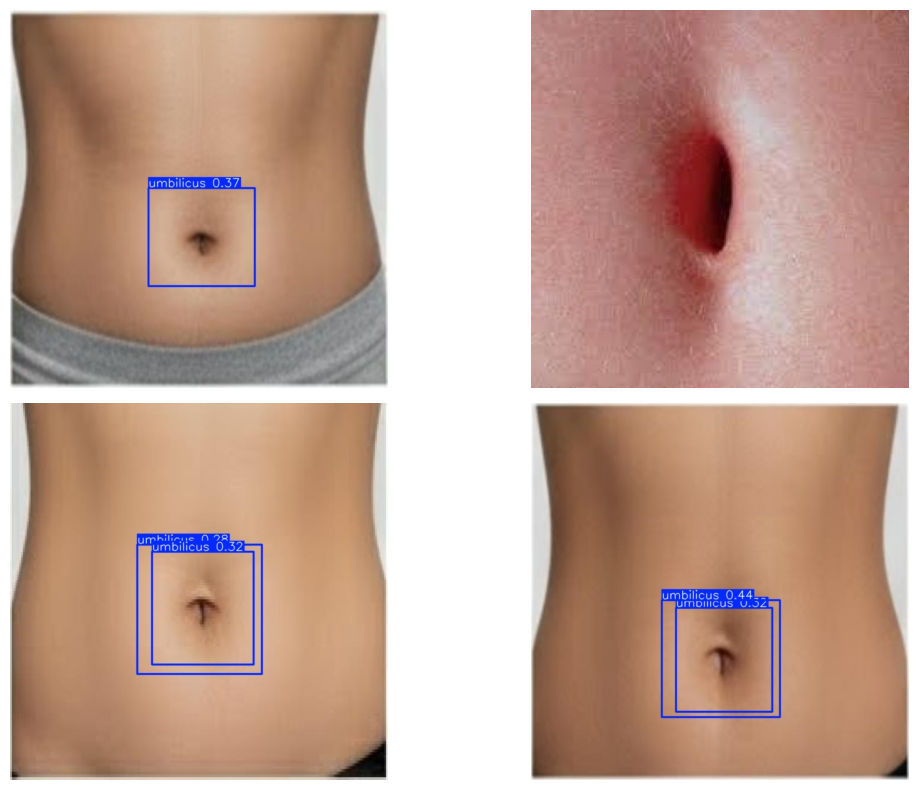

In [21]:
import glob

predict_folder = os.path.join("runs", "detect", "predict")

images = glob.glob(os.path.join(predict_folder, "*.jpg"))

print("Number of prediction images:", len(images))

plt.figure(figsize=(12,8))

for i, img_path in enumerate(images[:4]):   # show first 4 predictions
    img = Image.open(img_path)

    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Gradio Interface

A Gradio web interface is implemented to perform interactive inference with the trained YOLOv26 model.
Users can upload an abdominal image and the system will automatically detect the umbilicus and display the predicted bounding box with confidence score.

In [5]:
%pip install ultralytics gradio

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:

import os
import numpy as np
import gradio as gr
from PIL import Image, ImageDraw
from ultralytics import YOLO

# Model path
# Change this path to your actual best.pt path
MODEL_PATH = "/content/drive/MyDrive/umbilicus_yolo26/trial1/weights/best.pt"

print("Checking model path...")
print("MODEL_PATH:", MODEL_PATH)
print("Exists:", os.path.exists(MODEL_PATH))

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"Model not found: {MODEL_PATH}")

# Load YOLO model
model = YOLO(MODEL_PATH)
print("Model loaded successfully")

# Detection function
def detect_umbilicus(image):
    if image is None:
        return None, "No image uploaded."

    # Run YOLO inference
    results = model.predict(
        source=np.array(image),
        conf=0.25,
        iou=0.45,
        imgsz=640,
        verbose=False
    )

    result = results[0]

    # Prepare output image
    annotated = image.copy().convert("RGB")
    draw = ImageDraw.Draw(annotated)

    # If no detections
    if result.boxes is None or len(result.boxes) == 0:
        return annotated, "No umbilicus detected."

    # Select only the best detection (highest confidence)
    boxes = result.boxes
    confs = boxes.conf.cpu().numpy()
    best_idx = int(np.argmax(confs))
    best_box = boxes[best_idx]

    x1, y1, x2, y2 = [int(v) for v in best_box.xyxy[0].tolist()]
    conf = float(best_box.conf[0])
    cls_id = int(best_box.cls[0])
    cls_name = model.names[cls_id]

    # Draw bounding box
    draw.rectangle([x1, y1, x2, y2], outline="red", width=4)

    # Draw center point
    cx = (x1 + x2) // 2
    cy = (y1 + y2) // 2
    r = 5
    draw.ellipse((cx-r, cy-r, cx+r, cy+r), fill="yellow", outline="yellow")

    # Draw label text
    label = f"{cls_name}: {conf:.2f}"
    draw.text((x1, max(0, y1 - 15)), label, fill="red")

    # Summary text
    summary = (
        f"Detection: {cls_name}\n"
        f"Confidence: {conf:.3f}\n"
        f"Bounding box: [{x1}, {y1}, {x2}, {y2}]\n"
        f"Center point: ({cx}, {cy})"
    )

    return annotated, summary

# Build Gradio interface
interface = gr.Interface(
    fn=detect_umbilicus,
    inputs=gr.Image(type="pil", label="Upload abdominal image"),
    outputs=[
        gr.Image(type="pil", label="Detection result"),
        gr.Textbox(label="Detection summary")
    ],
    title="Umbilicus Detection using YOLOv26",
    description="Upload an abdominal image to detect the umbilicus."
)

# Launch app
interface.launch(share=True, debug=False)

Checking model path...
MODEL_PATH: /content/drive/MyDrive/umbilicus_yolo26/trial1/weights/best.pt
Exists: True
Model loaded successfully
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3fa2571f2812766452.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Discussion and Conclusion

- The YOLOv26 model successfully detected the umbilicus with accurate bounding box localisation.

- Predictions were generally consistent with the annotated ground truth, indicating that the model learned the visual features of the umbilicus effectively.

- The Gradio interface enabled interactive testing and real-time visualisation of detection results.

- The umbilicus detection module can serve as a reliable anatomical reference point for the AR-guided tele-palpation system.

- Future work may include expanding the dataset and improving model robustness for more diverse imaging conditions.